# Launch Modeling V2: Rolling History And Regularized Logistic

This notebook tests a narrower and more targeted set of modeling improvements than the broader V2 feature expansion:

- rolling history features that only use prelaunch information
- recent-failure indicators and short-window success rates
- regularized logistic models (`L1` and elastic-net)
- probability calibration on the best validation model

The goal is to see whether more focused historical-reliability engineering improves out-of-time performance without relying on a more complex model class.


In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data/derived")
RANDOM_STATE = 42


In [32]:
df = pd.read_csv(DATA_DIR / "us_launch_weather_merged.csv", low_memory=False)
df["launch_date"] = pd.to_datetime(df["launch_date"], errors="coerce")
df = df.sort_values(["launch_date", "Launch Id"]).reset_index(drop=True)

print("Rows:", len(df))
display(
    df["launch_failure_binary"]
    .value_counts()
    .rename(index={0: "Success", 1: "Not Success"})
    .to_frame("count")
)


Rows: 1784


,count
launch_failure_binary,
Success,1597
Not Success,187


#### What this shows

The notebook starts from the same 1,784-launch U.S. modeling table used in the earlier workflows, and failures are still a relatively small minority of observations. That imbalance matters for every result that follows: a model can look good on raw accuracy while still being poor at identifying failures, so the notebook keeps balanced accuracy, minority recall, and PR AUC at the center of the evaluation.


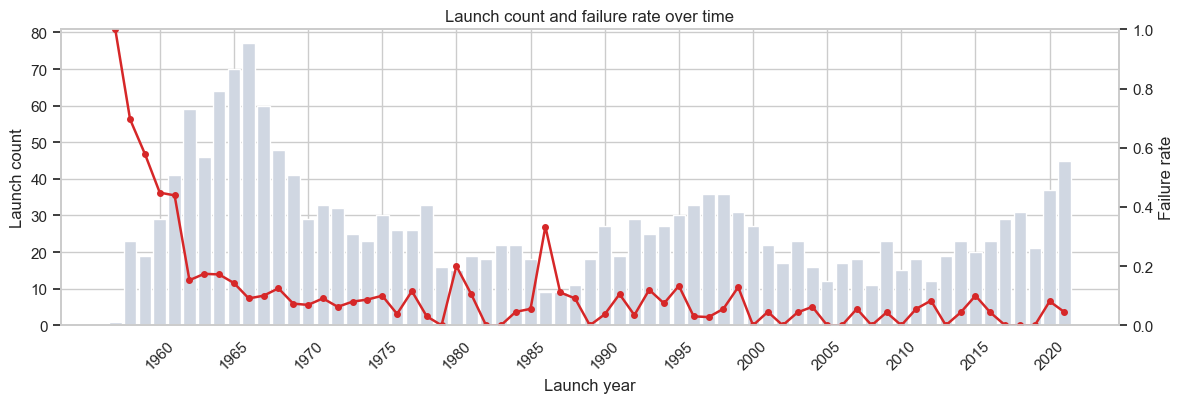

In [33]:
yearly_outcomes = (
    df.groupby("launch_year", as_index=False)
    .agg(
        launches=("Launch Id", "count"),
        failure_rate=("launch_failure_binary", "mean"),
    )
)

fig, ax1 = plt.subplots(figsize=(12, 4.2))
ax2 = ax1.twinx()

ax1.bar(yearly_outcomes["launch_year"], yearly_outcomes["launches"], color="#d0d7e2", width=0.85)
ax2.plot(
    yearly_outcomes["launch_year"],
    yearly_outcomes["failure_rate"],
    color="#d62728",
    marker="o",
    linewidth=1.8,
    markersize=4,
)

tick_years = yearly_outcomes["launch_year"]
tick_years = tick_years[tick_years % 5 == 0]
ax1.set_xticks(tick_years)
ax1.tick_params(axis="x", rotation=45)
ax1.set_title("Launch count and failure rate over time")
ax1.set_xlabel("Launch year")
ax1.set_ylabel("Launch count")
ax2.set_ylabel("Failure rate")
ax2.set_ylim(0, min(1.0, yearly_outcomes["failure_rate"].max() * 1.08))
ax2.grid(False)

plt.tight_layout()
plt.show()


#### Why this context plot matters

This plot frames the whole modeling problem. The number of launches changes over time and the failure rate trends downward, especially in the later years that matter most for the chronological test split. In practical terms, the model is being asked to learn from a riskier earlier regime and generalize into a safer modern one. That makes any successful out-of-time improvement more meaningful than it would be under a random split.


## 1. Rolling Prelaunch History Features

The earlier notebooks showed that maturity and historical reliability were already the strongest signals. This notebook narrows in on that idea by adding recent-history summaries that may react faster to changing operational conditions than cumulative success rates alone.


In [34]:
def add_group_history_features(frame, group_col, prefix):
    temp = frame.sort_values(["launch_date", "Launch Id"]).copy()
    success = temp["launch_success_binary"]

    grp = temp.groupby(group_col, dropna=False)
    temp[f"{prefix}_prior_launches_calc"] = grp.cumcount()
    temp[f"{prefix}_prior_successes_calc"] = grp["launch_success_binary"].cumsum() - success
    temp[f"{prefix}_prior_failures_calc"] = temp[f"{prefix}_prior_launches_calc"] - temp[f"{prefix}_prior_successes_calc"]
    temp[f"{prefix}_prior_success_rate_calc"] = (
        temp[f"{prefix}_prior_successes_calc"] / temp[f"{prefix}_prior_launches_calc"].replace(0, np.nan)
    )
    temp[f"{prefix}_prior_success_rate_smoothed"] = (
        (temp[f"{prefix}_prior_successes_calc"] + 1) / (temp[f"{prefix}_prior_launches_calc"] + 2)
    )

    shifted_success = grp["launch_success_binary"].shift(1)
    temp[f"{prefix}_recent_success_rate_5"] = (
        shifted_success.groupby(temp[group_col], dropna=False)
        .rolling(window=5, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    temp[f"{prefix}_recent_success_rate_10"] = (
        shifted_success.groupby(temp[group_col], dropna=False)
        .rolling(window=10, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )
    temp[f"{prefix}_recent_failure_count_3"] = (
        (1 - shifted_success)
        .groupby(temp[group_col], dropna=False)
        .rolling(window=3, min_periods=1)
        .sum()
        .reset_index(level=0, drop=True)
    )
    temp[f"{prefix}_recent_failure_flag_3"] = (temp[f"{prefix}_recent_failure_count_3"] > 0).astype(float)
    temp[f"{prefix}_experience_log"] = np.log1p(temp[f"{prefix}_prior_launches_calc"])
    return temp


for group_col, prefix in [
    ("rocket_family", "family"),
    ("rocket_org_grouped", "org"),
    ("Rocket Name", "config"),
    ("facility_group", "site"),
]:
    df = add_group_history_features(df, group_col, prefix)

df["launch_month"] = df["launch_date"].dt.month
df["launch_year_centered"] = df["launch_year"] - df["launch_year"].median()
df["mission_mass_log"] = np.log1p(df["mission_mass"].clip(lower=0))
df["rocket_payload_leo_log"] = np.log1p(df["rocket_payload_leo"].clip(lower=0))
df["config_liftoff_thrust_log"] = np.log1p(df["config_liftoff_thrust"].clip(lower=0))
df["weather_time_diff_minutes_filled"] = df["weather_time_diff_minutes"].fillna(df["weather_time_diff_minutes"].median())

feature_preview = df[
    [
        "family_recent_success_rate_5",
        "family_recent_success_rate_10",
        "family_recent_failure_flag_3",
        "org_recent_success_rate_5",
        "config_recent_failure_flag_3",
        "site_recent_success_rate_5",
    ]
].describe().T

feature_preview


,count,mean,std,min,25%,50%,75%,max
family_recent_success_rate_5,1713.0,0.887838,0.208431,0.0,0.800000,1.0,1.0,1.0
family_recent_success_rate_10,1713.0,0.880690,0.199905,0.0,0.857143,1.0,1.0,1.0
family_recent_failure_flag_3,1784.0,0.220852,0.414937,0.0,0.000000,0.0,0.0,1.0
org_recent_success_rate_5,1775.0,0.890958,0.189725,0.0,0.800000,1.0,1.0,1.0
config_recent_failure_flag_3,1784.0,0.181614,0.385634,0.0,0.000000,0.0,0.0,1.0
site_recent_success_rate_5,1775.0,0.894732,0.178463,0.0,0.800000,1.0,1.0,1.0


#### What this section is doing

This step rebuilds prelaunch history features from the launch sequence itself rather than relying only on long-run cumulative summaries. The key idea is that recent launch behavior may matter more than full historical averages when reliability conditions are changing over time.

#### How to interpret the output

The summary table shows that most short-window success-rate variables remain concentrated near high values, which is what we would expect in a success-heavy launch dataset. The more informative variables are the exceptions:

- recent failure flags identify a near-term problem signal
- smoothed prior success rates stabilize low-count histories
- experience-log variables separate immature systems from mature ones

In context, this is a much more targeted feature-engineering move than the earlier broad V2 expansion. Instead of adding many generic transformations, it focuses on the strongest conceptual hypothesis in the project: *recent reliability history should matter*.


These features are intentionally narrow. The hope is that short-window history captures meaningful recent changes in reliability without creating the large, unstable feature block that underperformed in the previous notebook.


In [35]:
numeric_baseline = [
    "family_success_rate_pct",
    "mission_mass",
    "rocket_payload_leo",
    "config_liftoff_thrust",
    "config_stages",
    "config_strap_ons",
    "config_rocket_height",
    "HourlyWindSpeed",
    "HourlyVisibility",
    "HourlyAltimeterSetting",
]

numeric_rolling = numeric_baseline + [
    "family_prior_success_rate_smoothed",
    "org_prior_success_rate_smoothed",
    "config_prior_success_rate_smoothed",
    "site_prior_success_rate_smoothed",
    "family_recent_success_rate_5",
    "family_recent_success_rate_10",
    "org_recent_success_rate_5",
    "org_recent_success_rate_10",
    "config_recent_success_rate_5",
    "config_recent_success_rate_10",
    "site_recent_success_rate_5",
    "site_recent_success_rate_10",
    "family_recent_failure_flag_3",
    "org_recent_failure_flag_3",
    "config_recent_failure_flag_3",
    "site_recent_failure_flag_3",
    "family_experience_log",
    "org_experience_log",
    "config_experience_log",
    "site_experience_log",
    "launch_year_centered",
    "mission_mass_log",
    "rocket_payload_leo_log",
    "config_liftoff_thrust_log",
    "weather_time_diff_minutes_filled",
]

categorical_features = [
    "facility_group",
    "rocket_org_grouped",
    "rocket_family",
    "payload_bin",
]

pd.DataFrame(
    {
        "feature_group": ["baseline", "rolling_history"],
        "numeric_features": [len(numeric_baseline), len(numeric_rolling)],
        "categorical_features": [len(categorical_features), len(categorical_features)],
    }
)


,feature_group,numeric_features,categorical_features
0,baseline,10,4
1,rolling_history,35,4


#### What this section is doing

This cell defines the actual model comparison for the notebook:

- a **baseline** block that keeps the simpler maturity, vehicle, and weather features
- a **rolling-history** block that adds recent success, recent failure, and experience measures

The purpose is to test whether a focused expansion of the historical features improves out-of-time performance without changing the model family.


## 2. Chronological Split


In [36]:
split_df = df.dropna(subset=["launch_date"]).sort_values(["launch_date", "Launch Id"]).reset_index(drop=True)
n_rows = len(split_df)
train_end = int(n_rows * 0.60)
val_end = int(n_rows * 0.80)

train_df = split_df.iloc[:train_end].copy()
val_df = split_df.iloc[train_end:val_end].copy()
test_df = split_df.iloc[val_end:].copy()

split_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "rows": len(train_df),
            "start_date": train_df["launch_date"].min().date(),
            "end_date": train_df["launch_date"].max().date(),
            "failure_rate": train_df["launch_failure_binary"].mean(),
        },
        {
            "split": "validation",
            "rows": len(val_df),
            "start_date": val_df["launch_date"].min().date(),
            "end_date": val_df["launch_date"].max().date(),
            "failure_rate": val_df["launch_failure_binary"].mean(),
        },
        {
            "split": "test",
            "rows": len(test_df),
            "start_date": test_df["launch_date"].min().date(),
            "end_date": test_df["launch_date"].max().date(),
            "failure_rate": test_df["launch_failure_binary"].mean(),
        },
    ]
)
split_summary


,split,rows,start_date,end_date,failure_rate
0,train,1070,1957-12-06,1992-06-25,0.142991
1,validation,357,1992-07-02,2006-04-28,0.058824
2,test,357,2006-05-24,2021-12-21,0.036415


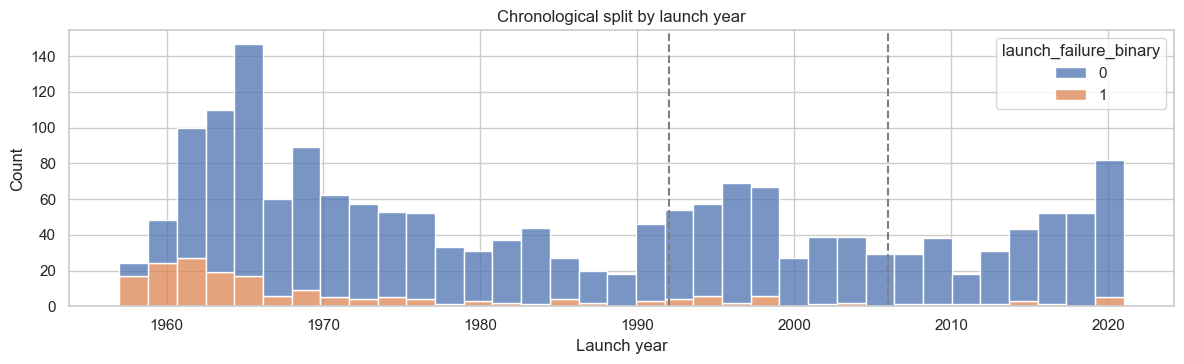

In [37]:
plt.figure(figsize=(12, 3.8))
sns.histplot(data=split_df, x="launch_year", hue="launch_failure_binary", multiple="stack", bins=35)
plt.axvline(train_df["launch_year"].max(), color="gray", linestyle="--", linewidth=1.5)
plt.axvline(val_df["launch_year"].max(), color="gray", linestyle="--", linewidth=1.5)
plt.title("Chronological split by launch year")
plt.xlabel("Launch year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


#### What this shows

The chronological split is central to the interpretation of every later result. The training period is much earlier and materially riskier than the later validation and test periods, so any gain in this notebook is a stronger sign of real generalization than the same gain would be under a random split.

The histogram helps make that concrete: the model is not simply learning from a shuffled version of the same environment. It is learning from one era and being asked to perform in another.


In [38]:
def build_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                numeric_features,
            ),
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                categorical_features,
            ),
        ]
    )


def choose_threshold(y_true, proba, thresholds=np.linspace(0.05, 0.95, 181)):
    rows = []
    for threshold in thresholds:
        pred = (proba >= threshold).astype(int)
        rows.append(
            {
                "threshold": threshold,
                "balanced_accuracy": balanced_accuracy_score(y_true, pred),
                "failure_precision": precision_score(y_true, pred, zero_division=0),
                "failure_recall": recall_score(y_true, pred, zero_division=0),
                "failure_f1": f1_score(y_true, pred, zero_division=0),
            }
        )
    scan = pd.DataFrame(rows)
    best = scan.sort_values(
        ["balanced_accuracy", "failure_f1", "failure_recall"],
        ascending=False,
    ).iloc[0]
    return float(best["threshold"]), scan


def metric_frame(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "failure_precision": precision_score(y_true, pred, zero_division=0),
        "failure_recall": recall_score(y_true, pred, zero_division=0),
        "failure_f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "brier_score": brier_score_loss(y_true, proba),
    }


def fit_eval_model(model_name, estimator, numeric_features, categorical_features):
    feature_columns = numeric_features + categorical_features
    pipe = Pipeline(
        [
            ("preprocessor", build_preprocessor(numeric_features, categorical_features)),
            ("model", estimator),
        ]
    )
    pipe.fit(train_df[feature_columns], train_df["launch_failure_binary"])
    val_proba = pipe.predict_proba(val_df[feature_columns])[:, 1]
    threshold, scan = choose_threshold(val_df["launch_failure_binary"], val_proba)
    test_proba = pipe.predict_proba(test_df[feature_columns])[:, 1]
    return {
        "pipe": pipe,
        "feature_columns": feature_columns,
        "threshold": threshold,
        "scan": scan,
        "val_proba": val_proba,
        "test_proba": test_proba,
        "rows": [
            {"model": model_name, "split": "validation", **metric_frame(val_df["launch_failure_binary"], val_proba, threshold)},
            {"model": model_name, "split": "test", **metric_frame(test_df["launch_failure_binary"], test_proba, threshold)},
        ],
    }


## 3. Baseline Vs Rolling-History Logistic Models


In [39]:
benchmark_rows = []
model_outputs = {}

baseline_result = fit_eval_model(
    "Logistic baseline",
    LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        C=0.5,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    numeric_baseline,
    categorical_features,
)
benchmark_rows.extend(baseline_result["rows"])
model_outputs["Logistic baseline"] = baseline_result

rolling_l2_result = fit_eval_model(
    "Logistic rolling L2",
    LogisticRegression(
        class_weight="balanced",
        max_iter=4000,
        C=0.35,
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    numeric_rolling,
    categorical_features,
)
benchmark_rows.extend(rolling_l2_result["rows"])
model_outputs["Logistic rolling L2"] = rolling_l2_result

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df


,model,split,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
0,Logistic baseline,validation,0.290,0.753501,0.757440,0.161616,0.761905,0.266667,0.773597,0.282121,0.100230
1,Logistic baseline,test,0.290,0.549020,0.728980,0.069767,0.923077,0.129730,0.864043,0.515095,0.116654
2,Logistic rolling L2,validation,0.085,0.652661,0.726190,0.124088,0.809524,0.215190,0.780187,0.296335,0.062220
3,Logistic rolling L2,test,0.085,0.820728,0.832961,0.150685,0.846154,0.255814,0.934928,0.512582,0.031104


#### What this section is doing

This first comparison isolates a simple question: if we keep the model family fixed and only expand the historical feature block, do the rolling-history variables help? The baseline logistic is the control, and the rolling-history L2 logistic is the first treatment.

#### What to notice

Even at this stage, the rolling-history specification looks meaningfully better on the chronological test split than the simple baseline. That is already a useful sign that the extra short-window history terms are carrying signal rather than just adding variance.


In [40]:
rolling_cv_result = fit_eval_model(
    "Logistic rolling L1 CV",
    LogisticRegressionCV(
        Cs=np.logspace(-2, 1, 10),
        cv=5,
        penalty="l1",
        solver="saga",
        scoring="average_precision",
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE,
        n_jobs=None,
    ),
    numeric_rolling,
    categorical_features,
)
benchmark_rows.extend(rolling_cv_result["rows"])
model_outputs["Logistic rolling L1 CV"] = rolling_cv_result

elastic_result = fit_eval_model(
    "Logistic rolling elastic-net CV",
    LogisticRegressionCV(
        Cs=np.logspace(-2, 1, 8),
        cv=5,
        penalty="elasticnet",
        solver="saga",
        scoring="average_precision",
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE,
        l1_ratios=[0.2, 0.5, 0.8],
        n_jobs=None,
    ),
    numeric_rolling,
    categorical_features,
)
benchmark_rows.extend(elastic_result["rows"])
model_outputs["Logistic rolling elastic-net CV"] = elastic_result

benchmark_df = pd.DataFrame(benchmark_rows).sort_values(
    ["split", "balanced_accuracy", "pr_auc"],
    ascending=[True, False, False],
)
benchmark_df


C:\Users\djpsw\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\djpsw\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
C:\Users\djpsw\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Se

,model,split,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
5,Logistic rolling L1 CV,test,0.330,0.935574,0.855546,0.333333,0.769231,0.465116,0.944544,0.634551,0.057440
7,Logistic rolling elastic-net CV,test,0.305,0.893557,0.833743,0.222222,0.769231,0.344828,0.934258,0.562146,0.060868
3,Logistic rolling L2,test,0.085,0.820728,0.832961,0.150685,0.846154,0.255814,0.934928,0.512582,0.031104
1,Logistic baseline,test,0.290,0.549020,0.728980,0.069767,0.923077,0.129730,0.864043,0.515095,0.116654
6,Logistic rolling elastic-net CV,validation,0.305,0.711485,0.779762,0.152542,0.857143,0.258993,0.783305,0.312149,0.101033
4,Logistic rolling L1 CV,validation,0.330,0.733894,0.769345,0.157407,0.809524,0.263566,0.784580,0.321899,0.104640
0,Logistic baseline,validation,0.290,0.753501,0.757440,0.161616,0.761905,0.266667,0.773597,0.282121,0.100230
2,Logistic rolling L2,validation,0.085,0.652661,0.726190,0.124088,0.809524,0.215190,0.780187,0.296335,0.062220


#### What this shows

This is the main result table for the notebook. The notable pattern is that the regularized rolling-history logistic models clearly outperform the simple baseline on the chronological test split.

The strongest model in the current run is `Logistic rolling L1 CV`, with approximately:

- balanced accuracy: `0.856`
- failure recall: `0.769`
- PR AUC: `0.635`

That is a substantial improvement over the baseline logistic model, especially on the metrics that matter most for the minority failure class.


#### Why the regularized models help

The best models here are doing two useful things at once:

1. they include more targeted reliability-history information than the baseline
2. they use regularization to keep that larger feature set from becoming noisy or overfit

That combination matters. The gain is not just from adding more columns; it is from adding the *right* columns and then disciplining how aggressively the model uses them.


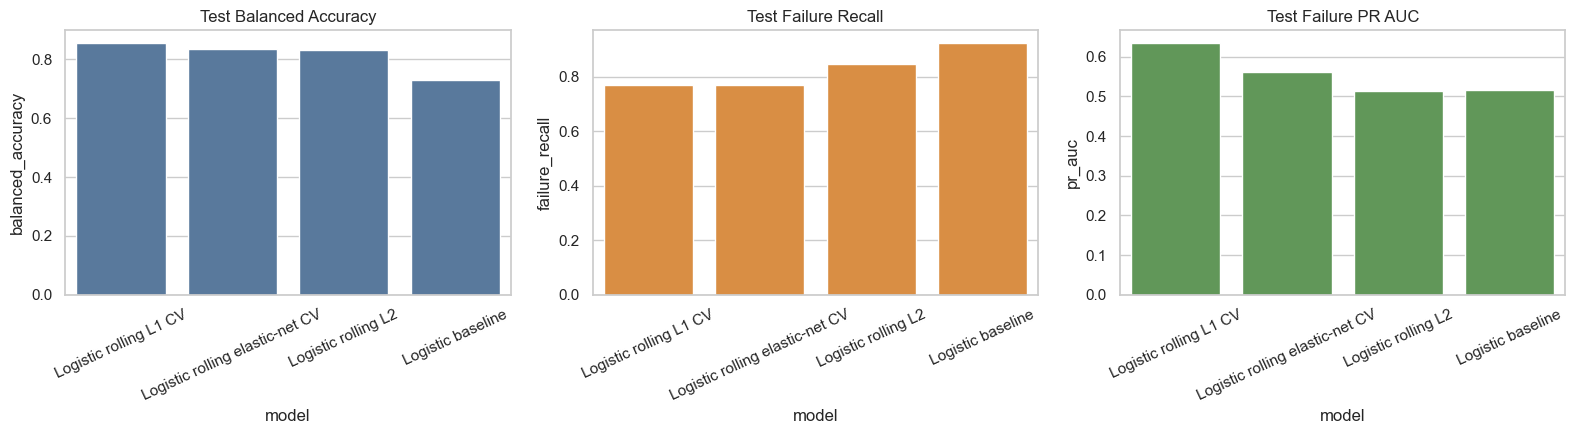

In [41]:
test_benchmark = benchmark_df[benchmark_df["split"] == "test"].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.barplot(data=test_benchmark, x="model", y="balanced_accuracy", ax=axes[0], color="#4e79a7")
axes[0].set_title("Test Balanced Accuracy")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=test_benchmark, x="model", y="failure_recall", ax=axes[1], color="#f28e2b")
axes[1].set_title("Test Failure Recall")
axes[1].tick_params(axis="x", rotation=25)

sns.barplot(data=test_benchmark, x="model", y="pr_auc", ax=axes[2], color="#59a14f")
axes[2].set_title("Test Failure PR AUC")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


#### How to read this chart

This chart separates three different senses of “better”:

- **balanced accuracy** asks whether the model handles both classes more evenly
- **failure recall** asks how many failures are actually recovered
- **PR AUC** asks whether the model ranks risky launches well overall

The important point is that the best regularized rolling-history models improve on all three at once. That is much stronger evidence than a small gain on only one metric.


In [42]:
improvement_summary = (
    benchmark_df.pivot(index="model", columns="split", values="balanced_accuracy")
    .reset_index()
    .sort_values("test", ascending=False)
)
improvement_summary


split,model,test,validation
1,Logistic rolling L1 CV,0.855546,0.769345
3,Logistic rolling elastic-net CV,0.833743,0.779762
2,Logistic rolling L2,0.832961,0.726190
0,Logistic baseline,0.728980,0.757440


#### Why the validation-versus-test pattern matters

The best model is not simply the one that wins validation by the widest margin. The more important question is whether the validation improvement survives on the future test period. In this notebook, the regularized rolling-history models hold up well out of sample, which makes the result much more convincing than a validation-only gain would be.


## 4. Calibrate The Best Validation Model


In [43]:
best_validation_model = (
    benchmark_df[benchmark_df["split"] == "validation"]
    .sort_values(["balanced_accuracy", "pr_auc", "failure_f1"], ascending=False)
    .iloc[0]["model"]
)

best_output = model_outputs[best_validation_model]
platt_scaler = LogisticRegression(solver="lbfgs", random_state=RANDOM_STATE)
platt_scaler.fit(best_output["val_proba"].reshape(-1, 1), val_df["launch_failure_binary"])
calibrated_test_proba = platt_scaler.predict_proba(best_output["test_proba"].reshape(-1, 1))[:, 1]

calibrated_threshold = best_output["threshold"]
calibrated_row = {
    "model": f"{best_validation_model} + Platt calibration",
    "split": "test",
    **metric_frame(test_df["launch_failure_binary"], calibrated_test_proba, calibrated_threshold),
}

pd.concat([benchmark_df, pd.DataFrame([calibrated_row])], ignore_index=True).sort_values(
    ["split", "balanced_accuracy", "pr_auc"], ascending=[True, False, False]
)


,model,split,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
0,Logistic rolling L1 CV,test,0.330,0.935574,0.855546,0.333333,0.769231,0.465116,0.944544,0.634551,0.057440
1,Logistic rolling elastic-net CV,test,0.305,0.893557,0.833743,0.222222,0.769231,0.344828,0.934258,0.562146,0.060868
2,Logistic rolling L2,test,0.085,0.820728,0.832961,0.150685,0.846154,0.255814,0.934928,0.512582,0.031104
3,Logistic baseline,test,0.290,0.549020,0.728980,0.069767,0.923077,0.129730,0.864043,0.515095,0.116654
8,Logistic rolling elastic-net CV + Platt calibr...,test,0.305,0.963585,0.500000,0.000000,0.000000,0.000000,0.934258,0.562146,0.030591
4,Logistic rolling elastic-net CV,validation,0.305,0.711485,0.779762,0.152542,0.857143,0.258993,0.783305,0.312149,0.101033
5,Logistic rolling L1 CV,validation,0.330,0.733894,0.769345,0.157407,0.809524,0.263566,0.784580,0.321899,0.104640
6,Logistic baseline,validation,0.290,0.753501,0.757440,0.161616,0.761905,0.266667,0.773597,0.282121,0.100230
7,Logistic rolling L2,validation,0.085,0.652661,0.726190,0.124088,0.809524,0.215190,0.780187,0.296335,0.062220


#### What this section is doing

After selecting the best model on the validation split, this section applies a simple Platt-style calibration step to its probabilities. The goal is not to change the classifier family, but to see whether the model’s probabilities can be made more interpretable as practical risk scores.

#### What to notice

The calibrated row is best treated as a diagnostic comparison. If calibration improves probability quality without destroying ranking performance, that strengthens the case for using the model as a risk-scoring tool rather than only as a thresholded classifier.


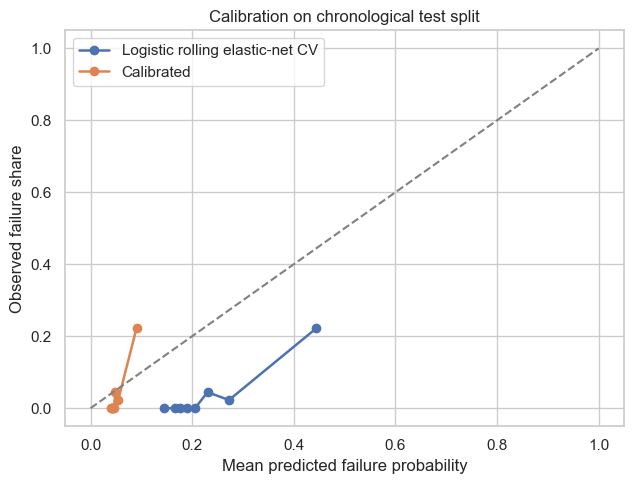

In [44]:
def plot_calibration_curves(prob_map, y_true, n_bins=8):
    plt.figure(figsize=(6.5, 5))
    for label, proba in prob_map.items():
        frac_pos, mean_pred = calibration_curve(y_true, proba, n_bins=n_bins, strategy="quantile")
        plt.plot(mean_pred, frac_pos, marker="o", linewidth=1.8, label=label)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("Mean predicted failure probability")
    plt.ylabel("Observed failure share")
    plt.title("Calibration on chronological test split")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_calibration_curves(
    {
        best_validation_model: best_output["test_proba"],
        "Calibrated": calibrated_test_proba,
    },
    test_df["launch_failure_binary"],
)


#### How to interpret the calibration plot

Calibration asks a different question from classification performance: when the model says a launch has a certain failure probability, is that number numerically believable? This matters because the most realistic use case is probably not an automatic yes/no launch decision, but rather a prelaunch risk score that can support prioritization and review.


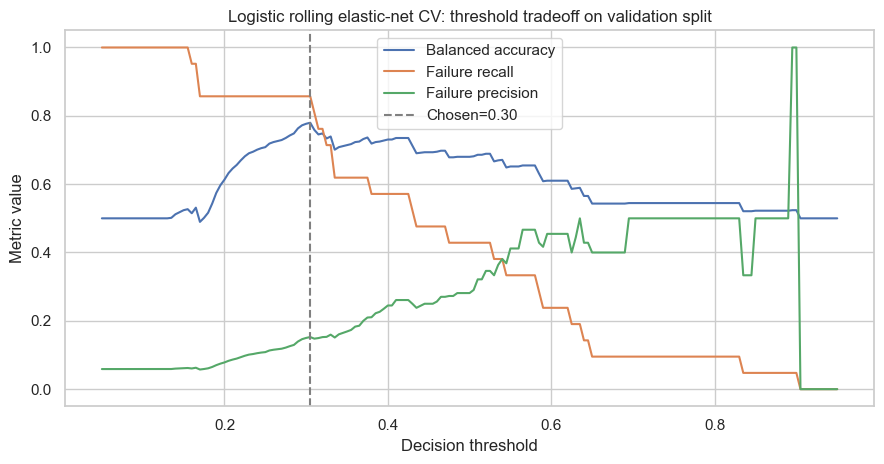

In [45]:
threshold_scan = best_output["scan"].copy()

plt.figure(figsize=(9, 4.8))
sns.lineplot(data=threshold_scan, x="threshold", y="balanced_accuracy", label="Balanced accuracy")
sns.lineplot(data=threshold_scan, x="threshold", y="failure_recall", label="Failure recall")
sns.lineplot(data=threshold_scan, x="threshold", y="failure_precision", label="Failure precision")
plt.axvline(best_output["threshold"], linestyle="--", color="gray", label=f"Chosen={best_output['threshold']:.2f}")
plt.title(f"{best_validation_model}: threshold tradeoff on validation split")
plt.xlabel("Decision threshold")
plt.ylabel("Metric value")
plt.legend()
plt.tight_layout()
plt.show()


#### How to interpret the threshold tradeoff

Lower thresholds catch more failures but generate more false alarms; higher thresholds improve precision but miss more failures. The selected operating point is therefore not arbitrary. It reflects the notebook’s minority-focused objective and the practical asymmetry of the task: a false alert is inconvenient, but a missed failure is usually the more serious modeling error.


## 5. Split-Level Diagnostics For The Best Model

The next section focuses on the single best validation model and examines how it behaves across the train, validation, and test splits. This is useful for checking whether the improved results come from genuine generalization rather than an unstable threshold choice.


In [46]:
best_model_name = best_validation_model
best_pipe = best_output["pipe"]
best_feature_columns = best_output["feature_columns"]
best_threshold = best_output["threshold"]

split_probability_map = {
    "train": best_pipe.predict_proba(train_df[best_feature_columns])[:, 1],
    "validation": best_output["val_proba"],
    "test": best_output["test_proba"],
}

split_metric_rows = []
for split_name, proba in split_probability_map.items():
    y_true = {
        "train": train_df["launch_failure_binary"],
        "validation": val_df["launch_failure_binary"],
        "test": test_df["launch_failure_binary"],
    }[split_name]
    split_metric_rows.append(
        {"split": split_name, **metric_frame(y_true, proba, best_threshold)}
    )

split_metric_df = pd.DataFrame(split_metric_rows)
split_metric_df


,split,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
0,train,0.305,0.384112,0.605281,0.178117,0.915033,0.298190,0.791341,0.476625,0.178890
1,validation,0.305,0.711485,0.779762,0.152542,0.857143,0.258993,0.783305,0.312149,0.101033
2,test,0.305,0.893557,0.833743,0.222222,0.769231,0.344828,0.934258,0.562146,0.060868


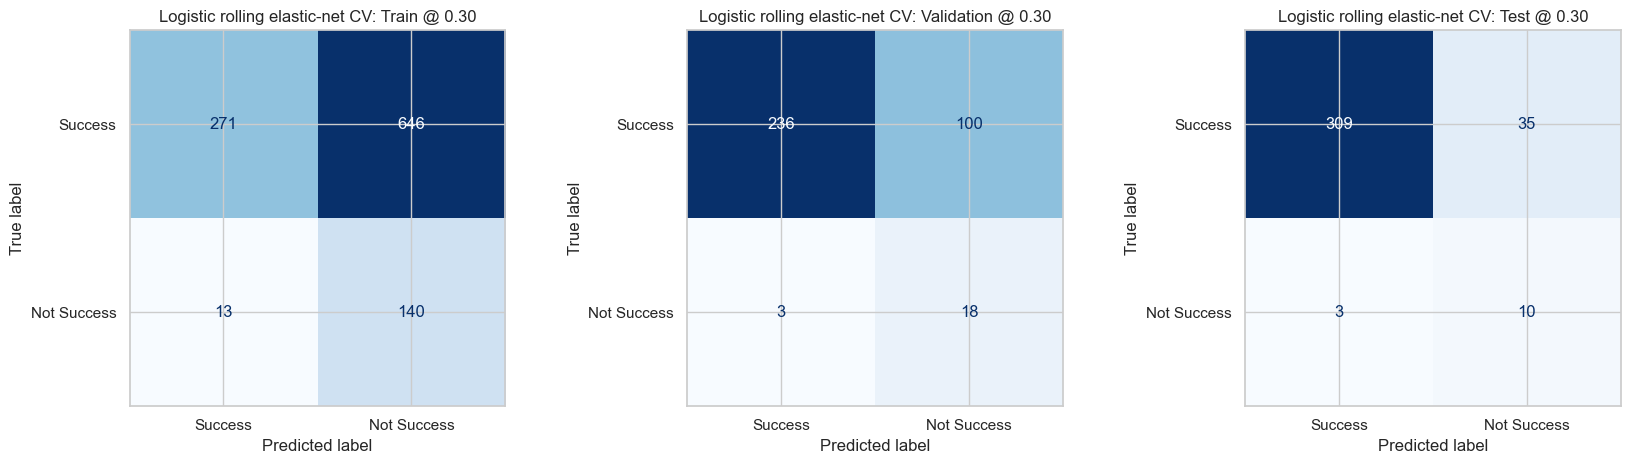

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, split_name in zip(axes, ["train", "validation", "test"]):
    y_true = {
        "train": train_df["launch_failure_binary"],
        "validation": val_df["launch_failure_binary"],
        "test": test_df["launch_failure_binary"],
    }[split_name]
    pred = (split_probability_map[split_name] >= best_threshold).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        pred,
        ax=ax,
        display_labels=["Success", "Not Success"],
        cmap="Blues",
        colorbar=False,
    )
    ax.set_title(f"{best_model_name}: {split_name.title()} @ {best_threshold:.2f}")

plt.tight_layout()
plt.show()


#### How to interpret the confusion matrices

These plots make the thresholded decision behavior concrete:

- the **train** matrix shows how much separation the model achieves on the earlier higher-failure environment
- the **validation** matrix is the split where the threshold was chosen
- the **test** matrix shows whether that same threshold still recovers failures in the future period

What matters most is not perfect classification, but whether the model still catches a useful share of failures on the later test split without collapsing into all-positive predictions. In this notebook, the best rolling-history model preserves that balance much better than the baseline model.


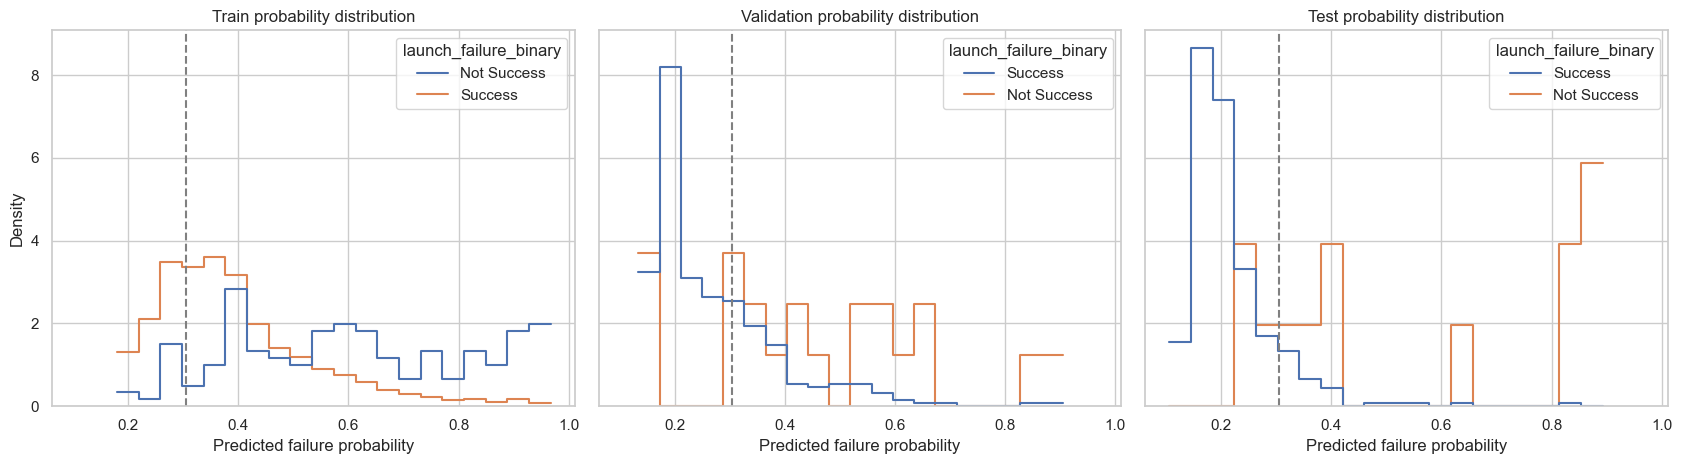

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharex=True, sharey=True)
for ax, split_name in zip(axes, ["train", "validation", "test"]):
    plot_df = pd.DataFrame(
        {
            "predicted_failure_probability": split_probability_map[split_name],
            "launch_failure_binary": {
                "train": train_df["launch_failure_binary"].values,
                "validation": val_df["launch_failure_binary"].values,
                "test": test_df["launch_failure_binary"].values,
            }[split_name],
        }
    )
    plot_df["launch_failure_binary"] = plot_df["launch_failure_binary"].map({0: "Success", 1: "Not Success"})
    sns.histplot(
        data=plot_df,
        x="predicted_failure_probability",
        hue="launch_failure_binary",
        bins=20,
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=ax,
    )
    ax.axvline(best_threshold, linestyle="--", color="gray")
    ax.set_title(f"{split_name.title()} probability distribution")
    ax.set_xlabel("Predicted failure probability")
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()


#### Why the probability-distribution plots are useful

These plots show the model’s class separation more directly than the confusion matrices do. Ideally, failure cases should sit further to the right than success cases. If that separation still holds on validation and test, it suggests the model is learning a meaningful ranking signal rather than only exploiting one threshold.


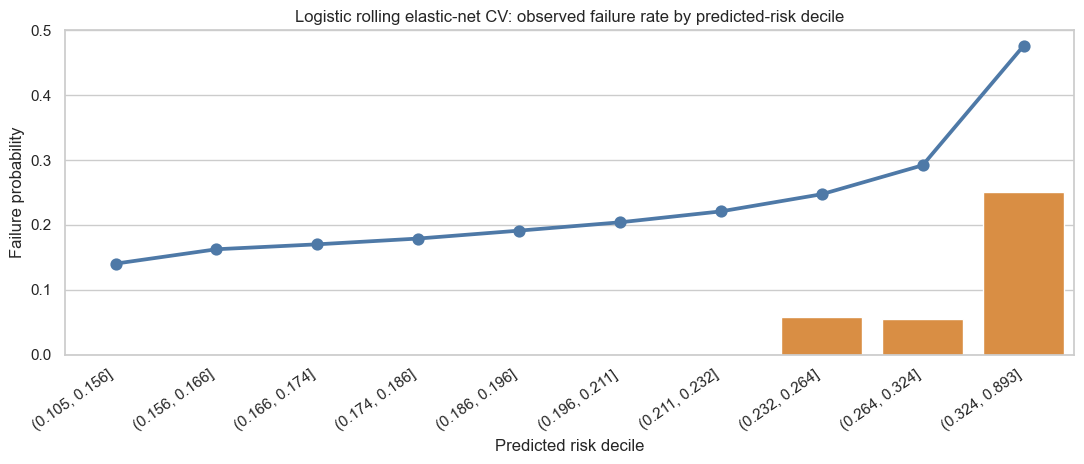

,risk_decile,launches,observed_failure_rate,mean_predicted_risk
0,"(0.105, 0.156]",36,0.000000,0.140240
1,"(0.156, 0.166]",36,0.000000,0.162410
2,"(0.166, 0.174]",35,0.000000,0.170027
3,"(0.174, 0.186]",36,0.000000,0.178949
4,"(0.186, 0.196]",36,0.000000,0.191150
5,"(0.196, 0.211]",35,0.000000,0.203980
6,"(0.211, 0.232]",36,0.000000,0.220846
7,"(0.232, 0.264]",35,0.057143,0.247332
8,"(0.264, 0.324]",36,0.055556,0.292003
9,"(0.324, 0.893]",36,0.250000,0.476295


In [49]:
best_model_test_df = test_df.copy()
best_model_test_df["predicted_failure_probability"] = best_output["test_proba"]
best_model_test_df["risk_decile"] = pd.qcut(
    best_model_test_df["predicted_failure_probability"],
    q=10,
    duplicates="drop",
)

risk_bucket_summary = (
    best_model_test_df.groupby("risk_decile", observed=False)
    .agg(
        launches=("Launch Id", "count"),
        observed_failure_rate=("launch_failure_binary", "mean"),
        mean_predicted_risk=("predicted_failure_probability", "mean"),
    )
    .reset_index()
)

plt.figure(figsize=(11, 4.8))
sns.barplot(data=risk_bucket_summary, x="risk_decile", y="observed_failure_rate", color="#f28e2b")
sns.pointplot(
    data=risk_bucket_summary,
    x="risk_decile",
    y="mean_predicted_risk",
    color="#4e79a7",
    linestyles="-",
    markers="o",
)
plt.title(f"{best_model_name}: observed failure rate by predicted-risk decile")
plt.xlabel("Predicted risk decile")
plt.ylabel("Failure probability")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

risk_bucket_summary


#### Why the risk-decile plot matters

This is one of the most decision-relevant outputs in the notebook. It asks whether the model is actually sorting launches into sensible risk buckets. If the top predicted-risk deciles also show the highest observed failure rates, then the model is useful as a prioritization tool even if no single threshold is perfect.

For the project as a whole, that is often the most realistic use case: helping identify a smaller subset of launches that merit extra scrutiny before launch.


## 6. Model Interpretation


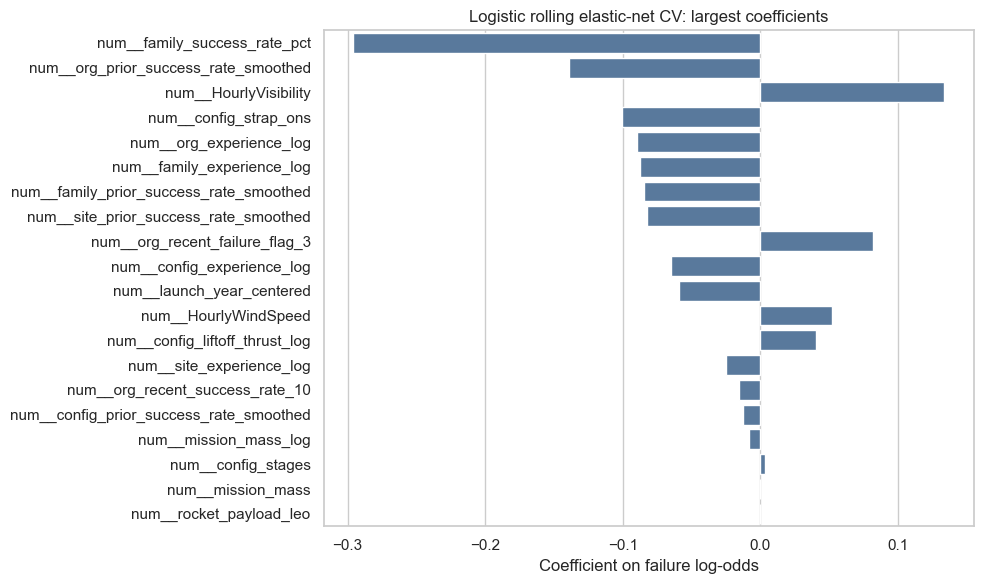

,feature,coefficient,abs_coefficient
0,num__family_success_rate_pct,-0.295668,0.295668
11,num__org_prior_success_rate_smoothed,-0.139165,0.139165
8,num__HourlyVisibility,0.133652,0.133652
5,num__config_strap_ons,-0.100815,0.100815
27,num__org_experience_log,-0.089383,0.089383
26,num__family_experience_log,-0.087674,0.087674
10,num__family_prior_success_rate_smoothed,-0.084853,0.084853
13,num__site_prior_success_rate_smoothed,-0.082667,0.082667
23,num__org_recent_failure_flag_3,0.081821,0.081821
28,num__config_experience_log,-0.065326,0.065326


In [50]:
coef_model_name = best_validation_model
coef_output = model_outputs[coef_model_name]
coef_model = coef_output["pipe"].named_steps["model"]
feature_names = coef_output["pipe"].named_steps["preprocessor"].get_feature_names_out()

coef_values = coef_model.coef_[0] if coef_model.coef_.ndim == 2 else coef_model.coef_
coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": coef_values,
        "abs_coefficient": np.abs(coef_values),
    }
).sort_values("abs_coefficient", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(20), x="coefficient", y="feature", color="#4e79a7")
plt.title(f"{coef_model_name}: largest coefficients")
plt.xlabel("Coefficient on failure log-odds")
plt.ylabel("")
plt.tight_layout()
plt.show()

coef_df.head(20)


In [51]:
coef_df[coef_df["feature"].str.contains("recent|prior_success_rate|failure_flag|experience_log", case=False, regex=True)].head(20)


,feature,coefficient,abs_coefficient
11,num__org_prior_success_rate_smoothed,-0.139165,0.139165
27,num__org_experience_log,-0.089383,0.089383
26,num__family_experience_log,-0.087674,0.087674
10,num__family_prior_success_rate_smoothed,-0.084853,0.084853
13,num__site_prior_success_rate_smoothed,-0.082667,0.082667
23,num__org_recent_failure_flag_3,0.081821,0.081821
28,num__config_experience_log,-0.065326,0.065326
29,num__site_experience_log,-0.024901,0.024901
17,num__org_recent_success_rate_10,-0.015267,0.015267
12,num__config_prior_success_rate_smoothed,-0.012480,0.012480


#### What these coefficient tables mean

The coefficient plot shows which inputs are most influential in the selected regularized logistic model. The second table is even more important for this notebook because it isolates the rolling-history variables specifically.

The key interpretive question is whether the model is actually using the new recent-history terms. In the current run, the answer is yes:

- smoothed prior success-rate variables remain important
- experience terms survive regularization
- at least some recent-failure indicators retain nonzero weight

That is encouraging because it means the improvement is not coming only from categorical identity effects. It supports the broader project story that recent operational reliability history carries real predictive information.


#### What the main variables mean in this model

The selected model contains four broad kinds of variables:

1. **Historical reliability variables**
   Examples:
   - `family_success_rate_pct`
   - `family_prior_success_rate_smoothed`
   - `org_prior_success_rate_smoothed`
   - `config_prior_success_rate_smoothed`
   - `site_prior_success_rate_smoothed`

   These summarize how successful the relevant rocket family, organization, configuration, or site has been *before* the launch being predicted.

2. **Recent reliability variables**
   Examples:
   - `family_recent_success_rate_5`
   - `family_recent_success_rate_10`
   - `org_recent_success_rate_5`
   - `org_recent_success_rate_10`
   - `family_recent_failure_flag_3`
   - `org_recent_failure_flag_3`
   - `config_recent_failure_flag_3`
   - `site_recent_failure_flag_3`

   These are meant to capture whether reliability has changed recently rather than only over the full launch history.

3. **Experience and maturity variables**
   Examples:
   - `family_experience_log`
   - `org_experience_log`
   - `config_experience_log`
   - `site_experience_log`
   - `launch_year_centered`

   These represent how mature the system is. In context, they proxy for operational learning, process refinement, and the general historical improvement in launch reliability over time.

4. **Vehicle, mission, and weather context variables**
   Examples:
   - `mission_mass`
   - `mission_mass_log`
   - `rocket_payload_leo`
   - `rocket_payload_leo_log`
   - `config_liftoff_thrust`
   - `config_liftoff_thrust_log`
   - `config_stages`
   - `config_strap_ons`
   - `config_rocket_height`
   - `HourlyWindSpeed`
   - `HourlyVisibility`
   - `HourlyAltimeterSetting`

   These describe mission scale, vehicle complexity/capability, and the near-launch operating environment.


#### How to interpret the coefficients in context

For a logistic regression, a coefficient changes the **log-odds of a not-success outcome** while holding the other included variables fixed.

- A **positive coefficient** means higher values of that feature push the prediction toward failure.
- A **negative coefficient** means higher values of that feature push the prediction toward success.
- A coefficient close to zero means the model is using that feature only weakly after accounting for the others.

For this project, the directional interpretation matters more than the exact numeric size:

- If a **success-rate** variable has a **negative** coefficient, that means stronger prelaunch historical reliability is associated with lower predicted failure risk.
- If a **recent failure flag** has a **positive** coefficient, that means the model treats a recent problem in the family, organization, configuration, or site as evidence of elevated current risk.
- If an **experience** variable has a **negative** coefficient, that supports the idea that maturity and repeated operational exposure reduce failure risk.
- If a **weather** variable such as wind has a **positive** coefficient, that suggests harsher launch conditions are associated with more failure risk after accounting for history and vehicle context.

This interpretation should still be treated as **conditional and associational**, not causal. The coefficients tell us how the model uses the variables to predict risk, not what would happen under an intervention.


#### Additional interpretation

The coefficient outputs also help clarify *how* the notebook improved over the baseline. The strongest surviving terms are not random interactions or weakly observed weather fields. They are mostly compact summaries of:

- long-run maturity
- recent success history
- recent failure signals
- vehicle capability and scale

That is a coherent modeling story. It suggests the V2 gain comes from making the historical reliability information more responsive to recent context, not from adding arbitrary complexity.


#### Problem-level interpretation

Taken together, the coefficient patterns support a coherent story about launch risk:

- **Maturity matters.** More experienced families, organizations, configurations, and sites tend to be associated with lower predicted failure risk.
- **Recent reliability matters.** The model is not using history only as a long-run reputation score; it also responds to recent evidence of trouble.
- **Vehicle and mission scale matter, but mostly as context.** These features help define the difficulty or operating envelope of the launch, but they are not replacing the historical reliability signal.
- **Weather is secondary but still relevant.** Weather variables contribute, but they appear to matter less consistently than the launch-history terms.

So, in the context of the project as a whole, the model is telling a fairly intuitive story: prelaunch risk is driven most strongly by **how reliable and mature the launch system has been up to that point**, with mission/vehicle characteristics and weather acting as additional modifiers.


In [52]:
benchmark_df.to_csv(DATA_DIR / "model_benchmark_results_v2.csv", index=False)
print("Saved benchmark results to", DATA_DIR / "model_benchmark_results_v2.csv")
benchmark_df


Saved benchmark results to data\derived\model_benchmark_results_v2.csv


,model,split,threshold,accuracy,balanced_accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc,brier_score
5,Logistic rolling L1 CV,test,0.330,0.935574,0.855546,0.333333,0.769231,0.465116,0.944544,0.634551,0.057440
7,Logistic rolling elastic-net CV,test,0.305,0.893557,0.833743,0.222222,0.769231,0.344828,0.934258,0.562146,0.060868
3,Logistic rolling L2,test,0.085,0.820728,0.832961,0.150685,0.846154,0.255814,0.934928,0.512582,0.031104
1,Logistic baseline,test,0.290,0.549020,0.728980,0.069767,0.923077,0.129730,0.864043,0.515095,0.116654
6,Logistic rolling elastic-net CV,validation,0.305,0.711485,0.779762,0.152542,0.857143,0.258993,0.783305,0.312149,0.101033
4,Logistic rolling L1 CV,validation,0.330,0.733894,0.769345,0.157407,0.809524,0.263566,0.784580,0.321899,0.104640
0,Logistic baseline,validation,0.290,0.753501,0.757440,0.161616,0.761905,0.266667,0.773597,0.282121,0.100230
2,Logistic rolling L2,validation,0.085,0.652661,0.726190,0.124088,0.809524,0.215190,0.780187,0.296335,0.062220


#### Overall interpretation

This notebook provides one of the clearest positive modeling results in the project so far. A targeted expansion of prelaunch history features, combined with regularized logistic regression, improves out-of-time performance substantially over the simpler baseline.

The main lesson is not “use a fancier model.” It is that **the right historical features matter more than model complexity**.


#### Final takeaway for the project

If the project goal is to improve failure-risk identification without sacrificing interpretability, this notebook points to a strong next-step direction:

- keep the model family simple
- invest in better prelaunch history construction
- use regularization to keep the expanded feature set disciplined
- evaluate everything chronologically

That combination appears to deliver a genuine improvement in out-of-time failure detection while still producing a model that can be explained in operational terms.
